# Lesson 6.2 — Singular Values and the Condition Number
**Module 6 · Unit 6 · Lesson 22**

κ = σ_max/σ_min measures **shape**; it fixes the Yoshikawa volume blind spot. θ₂ and π−θ₂ share the same w but different κ.

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
P2=[(0,0,1,0),(0,0,1,0)]; T2=["R","R"]
P3=[(0,0,1,0),(0,0,1,0),(0,0,0.6,0)]; T3=["R","R","R"]


## Condition number grows toward a singularity; isotropy = 1/κ

In [2]:
checks=[]
for t2 in [1.4,0.6,0.15]:
    s=np.linalg.svd(Jv_planar(P2,T2,np.array([0.4,t2])),compute_uv=False)
    print(f"theta2={t2}: sigma=({s[0]:.3f},{s[1]:.3f})  kappa={s[0]/s[1]:.2f}  isotropy={s[1]/s[0]:.3f}")
s=np.linalg.svd(Jv_planar(P2,T2,np.array([0.4,0.05])),compute_uv=False)
checks.append(s[0]/s[1]>50)

theta2=1.4: sigma=(1.737,0.567)  kappa=3.06  isotropy=0.327
theta2=0.6: sigma=(2.140,0.264)  kappa=8.11  isotropy=0.123
theta2=0.15: sigma=(2.230,0.067)  kappa=33.28  isotropy=0.030


## The blind-spot fix: equal w, different κ (θ₂ vs π−θ₂)

In [3]:
def wk(q):
    s=np.linalg.svd(Jv_planar(P2,T2,q),compute_uv=False); return float(np.prod(s)), float(s[0]/s[1])
wa,ka=wk(np.array([0.3,0.6])); wb,kb=wk(np.array([0.3,np.pi-0.6]))
print(f"theta2=0.60 (extended): w={wa:.3f}  kappa={ka:.2f}")
print(f"theta2={np.pi-0.6:.2f} (folded):   w={wb:.3f}  kappa={kb:.2f}")
print("-> same w, different kappa: w (volume) is blind to shape; kappa is not")
checks.append(np.isclose(wa,wb,atol=1e-6) and abs(ka-kb)>1.0)

theta2=0.60 (extended): w=0.565  kappa=8.11
theta2=2.54 (folded):   w=0.565  kappa=1.85
-> same w, different kappa: w (volume) is blind to shape; kappa is not


## Sweep to straight: κ → ∞ while w → 0

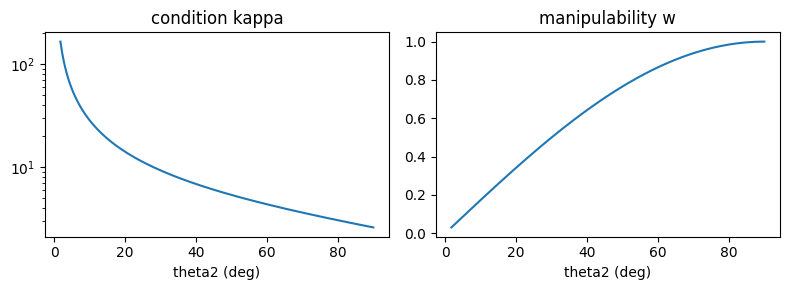

All checks passed.


In [4]:
import matplotlib.pyplot as plt
t2=np.linspace(0.03,np.pi/2,200)
kap=[wk(np.array([0.3,t]))[1] for t in t2]; w=[wk(np.array([0.3,t]))[0] for t in t2]
fig,ax=plt.subplots(1,2,figsize=(8,3))
ax[0].plot(np.degrees(t2),kap); ax[0].set_title('condition kappa'); ax[0].set_xlabel('theta2 (deg)'); ax[0].set_yscale('log')
ax[1].plot(np.degrees(t2),w); ax[1].set_title('manipulability w'); ax[1].set_xlabel('theta2 (deg)')
plt.tight_layout(); plt.show()
checks.append(kap[0]>kap[-1] and w[0]<w[-1])
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")